In [1]:
!git clone https://github.com/AInMicLab/deep-image-prior.git
!mv deep-image-prior/* ./

Cloning into 'deep-image-prior'...
remote: Enumerating objects: 308, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 308 (delta 4), reused 6 (delta 4), pack-reused 299 (from 2)
Receiving objects: 100% (308/308), 102.13 MiB | 14.20 MiB/s, done.
Resolving deltas: 100% (160/160), done.
Updating files: 100% (52/52), done.


In [2]:
import wandb

In [3]:
# !git init

In [4]:
!wandb init

Let's setup this directory for W&B!
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shriramgolla (shriramgolla-iit-hyderabad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Which project should we use?
wandb: (1) sr_dprior
wandb: (2) my-awesome-project
wandb: (3) Create New
wandb: Enter your choice: 1
wandb: You chose 'sr_dprior'
wandb: Updated settings file /content/wandb/settings
This directory is configured!  Next, track a run:
* In your training script:
    import wandb
    wandb.init(project="sr_dprior")
* then `python <train.py>`.



In [19]:
from __future__ import print_function
import matplotlib.pyplot as plt
%matplotlib inline

import argparse
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import numpy as np
from models import *

import torch
import torch.optim

# from skimage.measure import compare_psnr
def compare_psnr(img1, img2):
    import math
    from skimage.metrics import peak_signal_noise_ratio as psnr
    return psnr(img1, img2)

from models.downsampler import Downsampler

from utils.sr_utils import *

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark =True
dtype = torch.cuda.FloatTensor

imsize = -1
factor = 4 # 8
enforse_div32 = 'CROP'
PLOT = True
path_to_image = '/content/Pokemon.jpg'

In [18]:
# import requests
# from PIL import Image
# from io import BytesIO

# url = "https://eriktwice.com/wp-content/uploads/2019/01/Pokemon.Battle.Red_.3.Team_-1.jpg"
# response = requests.get(url)
# image = Image.open(BytesIO(response.content))

In [20]:
fname = 'Pokemon.jpg'

HR and LR resolutions: (1056, 544), (264, 136)


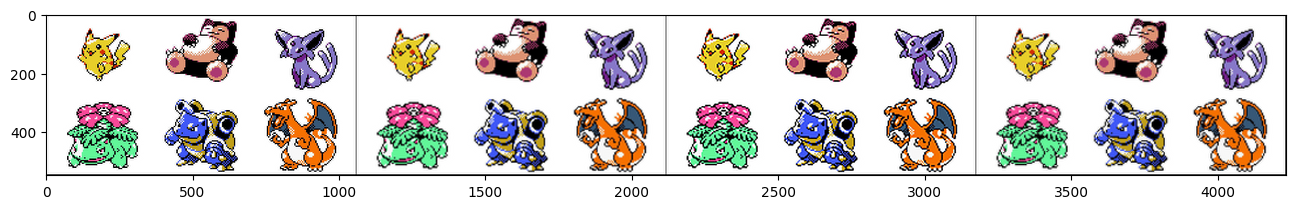

PSNR bicubic: 18.2291   PSNR nearest: 17.1061


In [21]:
# Starts here
imgs = load_LR_HR_imgs_sr(path_to_image , imsize, factor, enforse_div32)

imgs['bicubic_np'], imgs['sharp_np'], imgs['nearest_np'] = get_baselines(imgs['LR_pil'], imgs['HR_pil'])

if PLOT:
    plot_image_grid([imgs['HR_np'], imgs['bicubic_np'], imgs['sharp_np'], imgs['nearest_np']], 4,12);
    print ('PSNR bicubic: %.4f   PSNR nearest: %.4f' %  (
                                        compare_psnr(imgs['HR_np'], imgs['bicubic_np']),
                                        compare_psnr(imgs['HR_np'], imgs['nearest_np'])))

In [22]:
input_depth = 32

INPUT =     'noise'
pad   =     'reflection'
OPT_OVER =  'net'
KERNEL_TYPE='lanczos2'

LR = 0.01
tv_weight = 0.0

OPTIMIZER = 'adam'

if factor == 4:
    num_iter = 2000
    reg_noise_std = 0.03
elif factor == 8:
    num_iter = 4000
    reg_noise_std = 0.05

In [23]:
net_input = get_noise(input_depth, INPUT, (imgs['HR_pil'].size[1], imgs['HR_pil'].size[0])).type(dtype).detach()

NET_TYPE = 'skip' # UNet, ResNet
net = get_net(input_depth, 'skip', pad,
              skip_n33d=128,
              skip_n33u=128,
              skip_n11=4,
              num_scales=5,
              upsample_mode='bilinear').type(dtype)

# Losses
mse = torch.nn.MSELoss().type(dtype)

img_LR_var = np_to_torch(imgs['LR_np']).type(dtype)

downsampler = Downsampler(n_planes=3, factor=factor, kernel_type=KERNEL_TYPE, phase=0.5, preserve_size=True).type(dtype)

In [24]:
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="shriramgolla-iit-hyderabad",
    # Set the wandb project where this run will be logged.
    project="SR_Pokemon",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.02,
        "architecture": "DeepPrior",
        "dataset": "Pokemong.jpg",
        "epochs": 1,
    },
)

wandb: Loading settings from /content/wandb/settings
/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: shriramgolla (shriramgolla-iit-hyderabad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [25]:
def closure():
    global i, net_input

    if reg_noise_std > 0:
        net_input = net_input_saved + (noise.normal_() * reg_noise_std)

    out_HR = net(net_input)
    out_LR = downsampler(out_HR)

    total_loss = mse(out_LR, img_LR_var)

    if tv_weight > 0:
        total_loss += tv_weight * tv_loss(out_HR)

    total_loss.backward()

    # Log
    psnr_LR = compare_psnr(imgs['LR_np'], torch_to_np(out_LR))
    psnr_HR = compare_psnr(imgs['HR_np'], torch_to_np(out_HR))
    print ('Iteration %05d    PSNR_LR %.3f   PSNR_HR %.3f' % (i, psnr_LR, psnr_HR), '\r', end='')

    run.log({"psnr_LR":psnr_LR, "psnr_HR":psnr_HR})

    # History
    psnr_history.append([psnr_LR, psnr_HR])

    if PLOT and i % 100 == 0:
        out_HR_np = torch_to_np(out_HR)
        plot_image_grid([imgs['HR_np'], imgs['bicubic_np'], np.clip(out_HR_np, 0, 1)], factor=13, nrow=3)

        run.log({"image": wandb.Image(np_to_pil(np.clip(out_HR_np, 0, 1)),caption = f"Image at {i} iter"  )})

    i += 1

    return total_loss

Starting optimization with ADAM


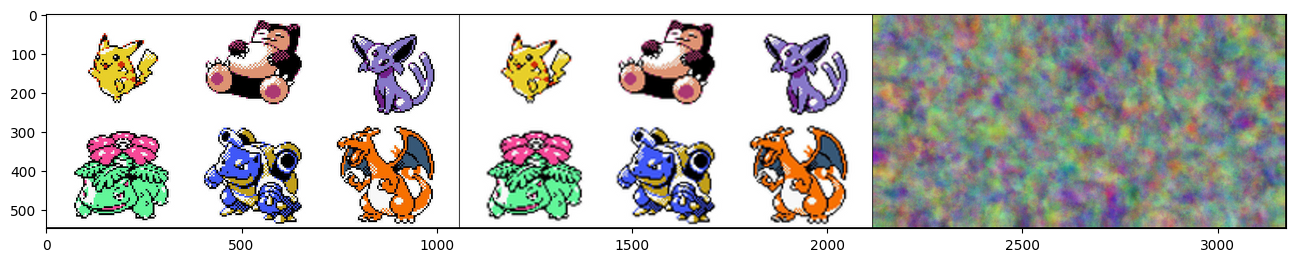

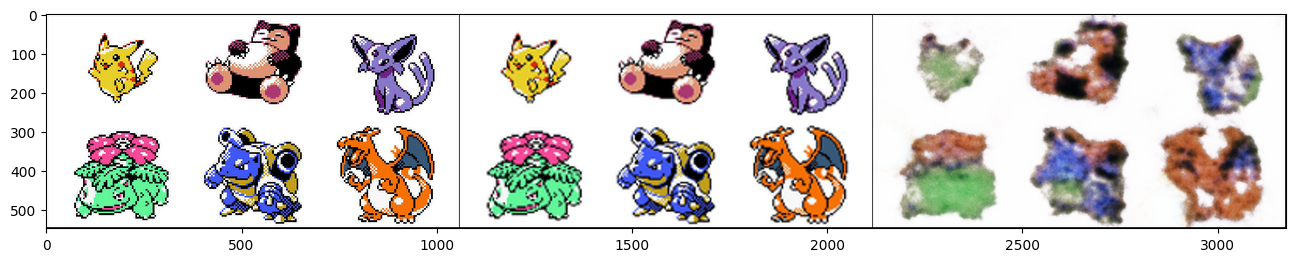

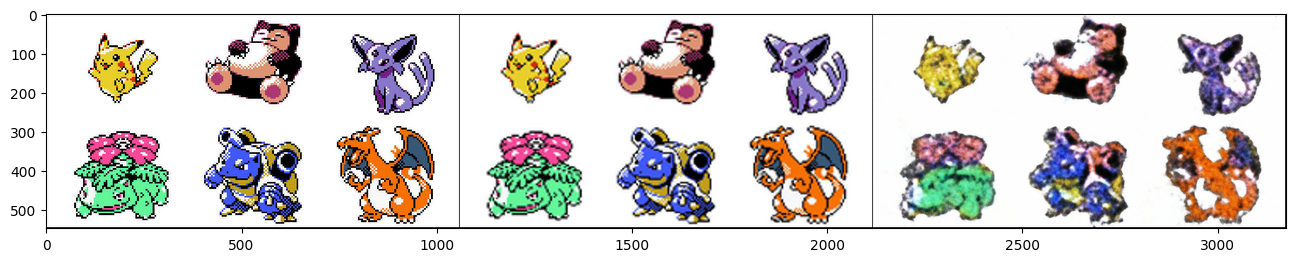

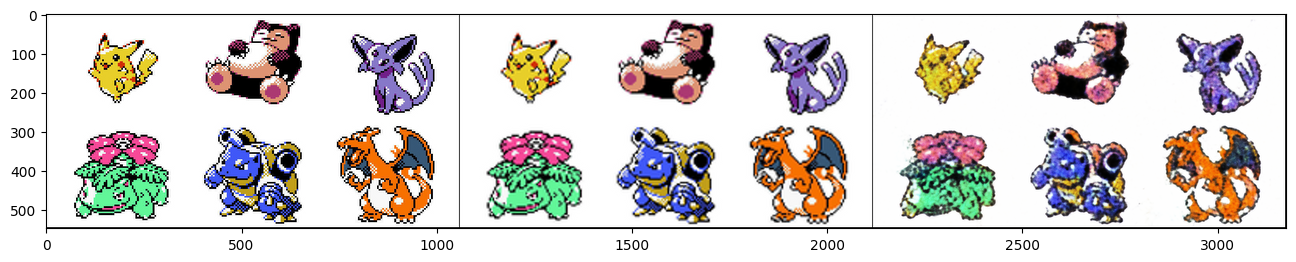

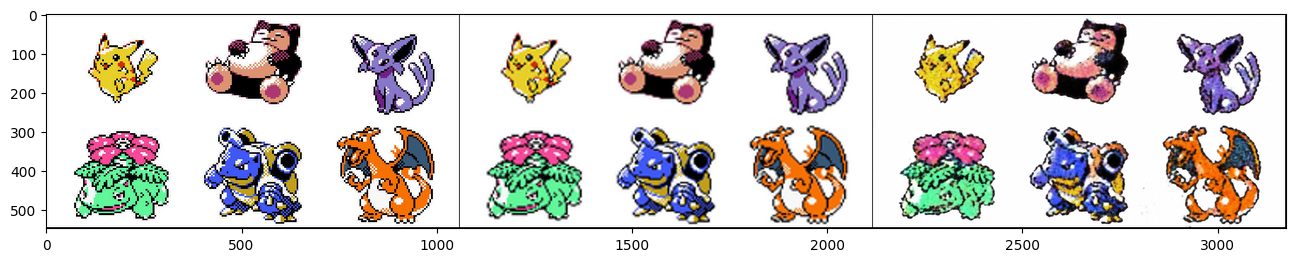

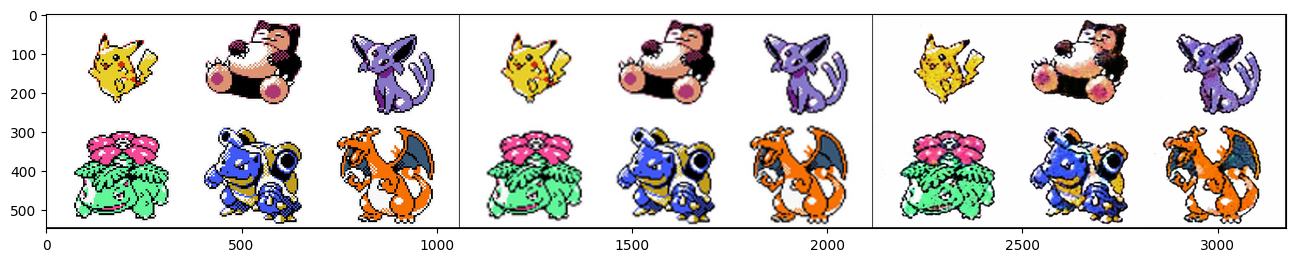

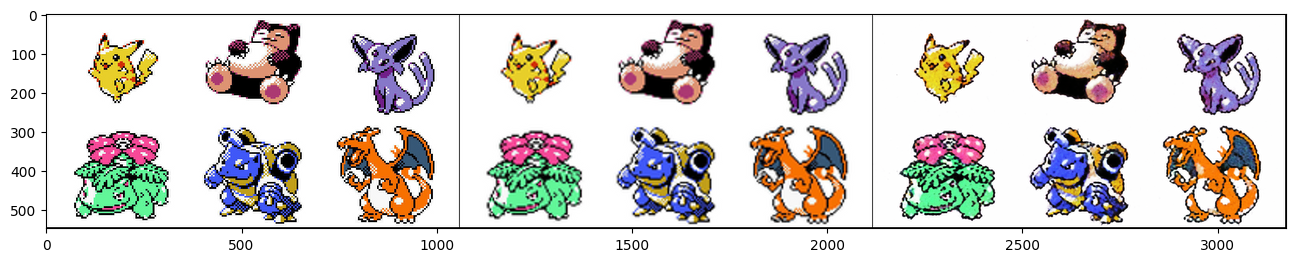

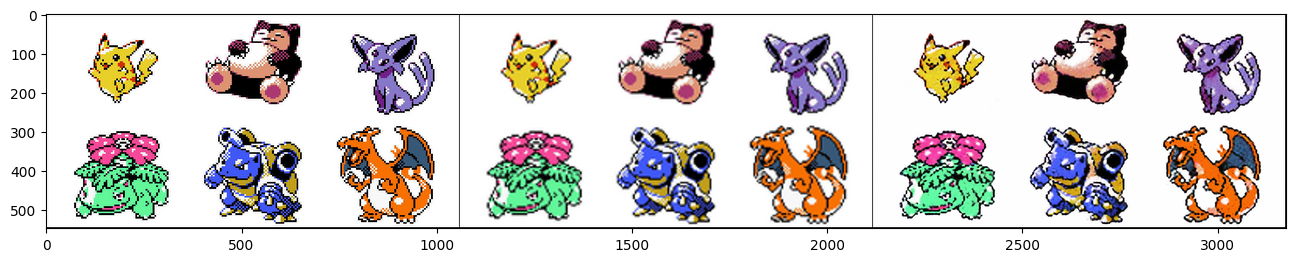

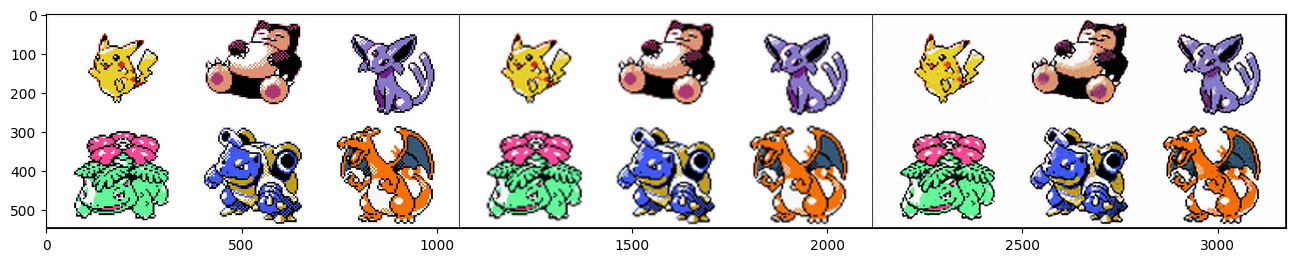

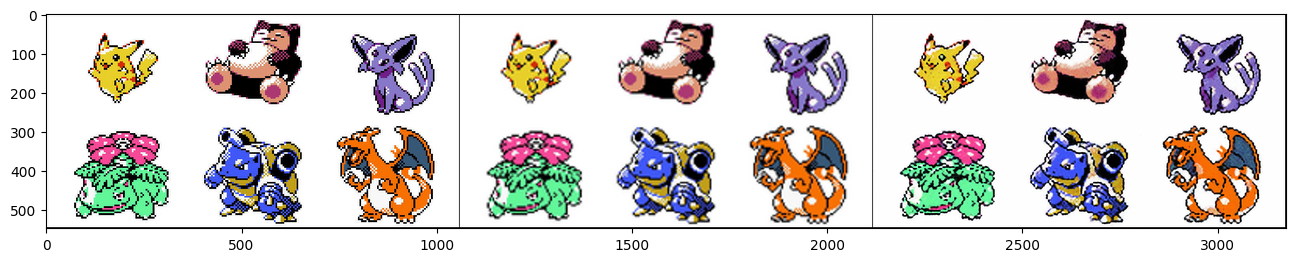

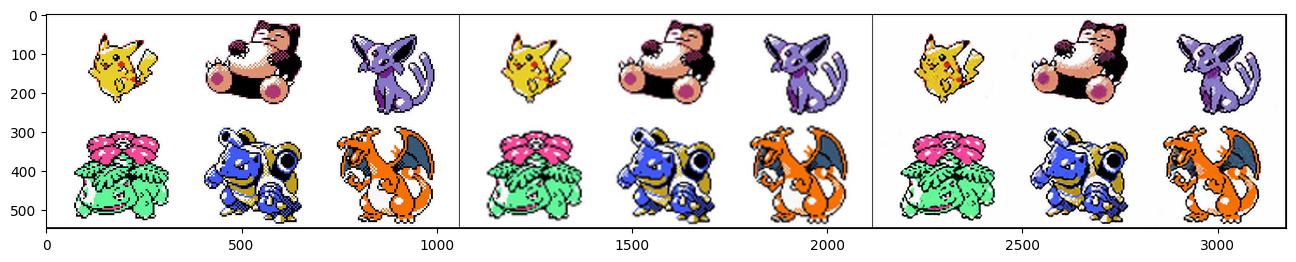

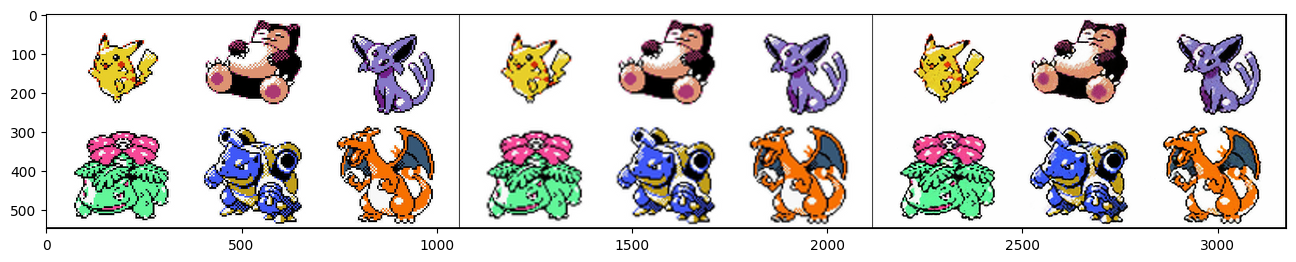

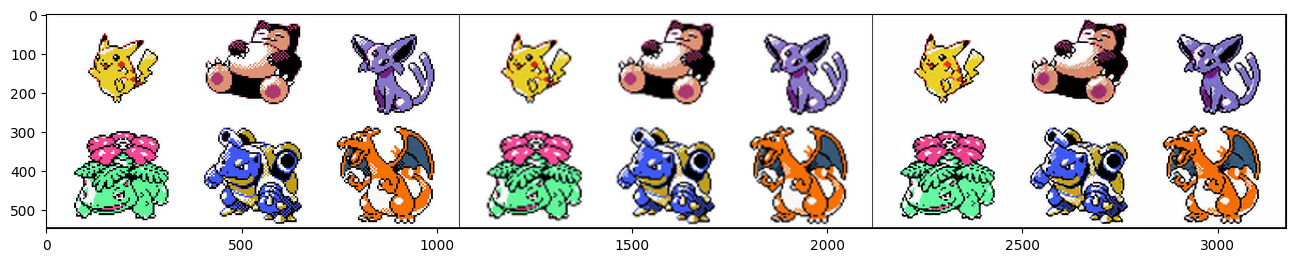

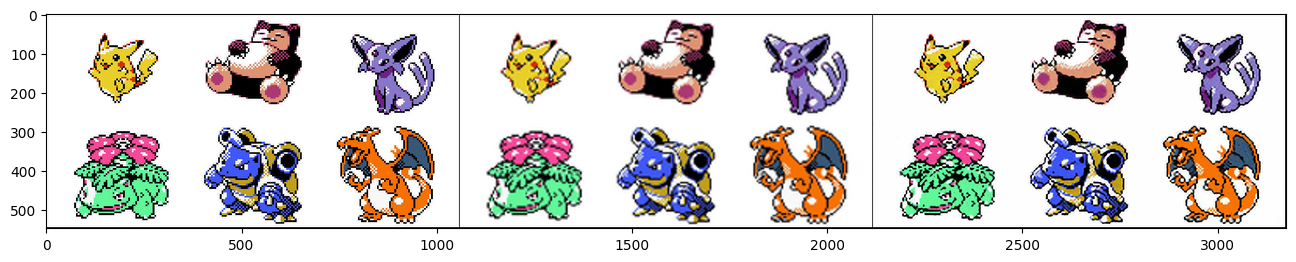

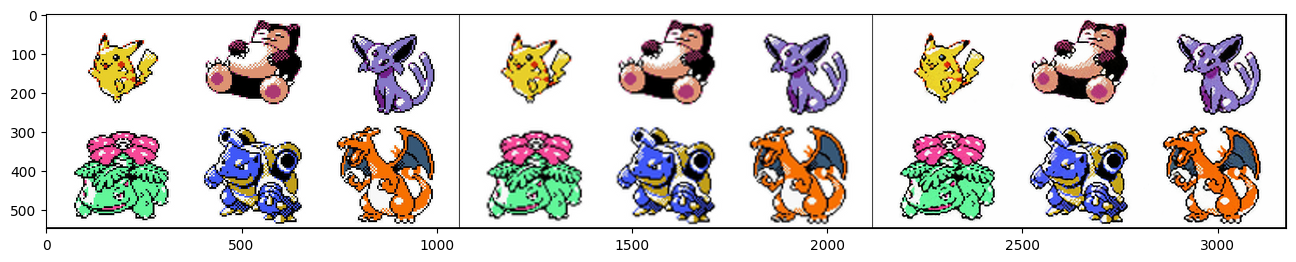

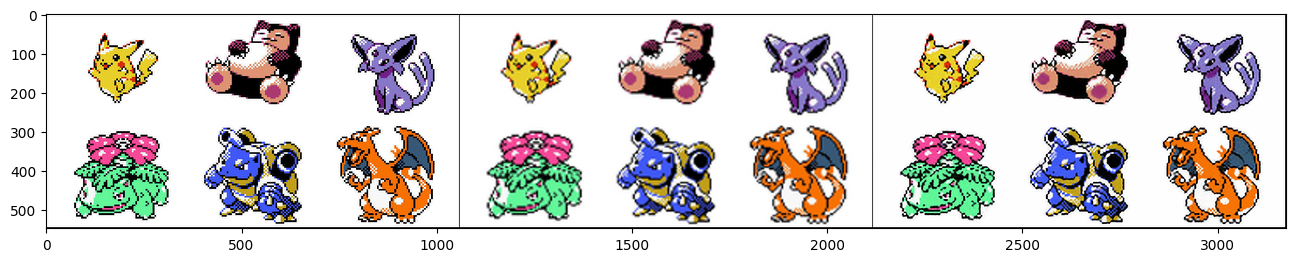

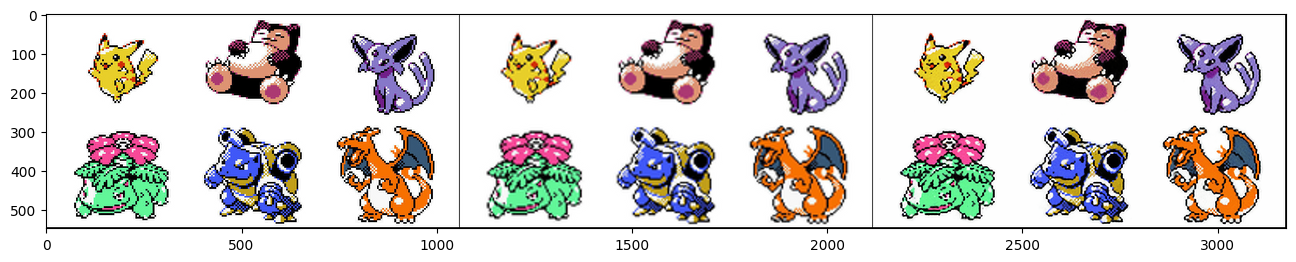

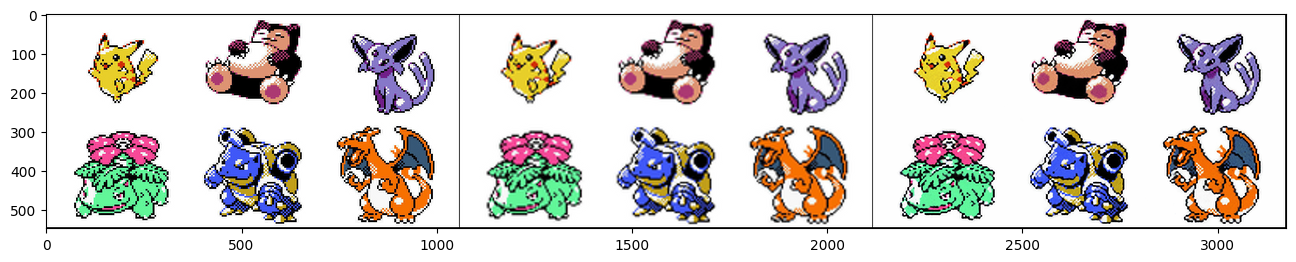

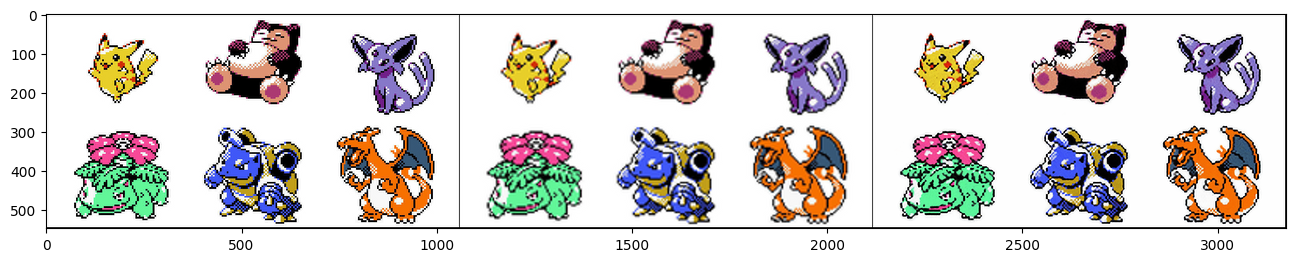

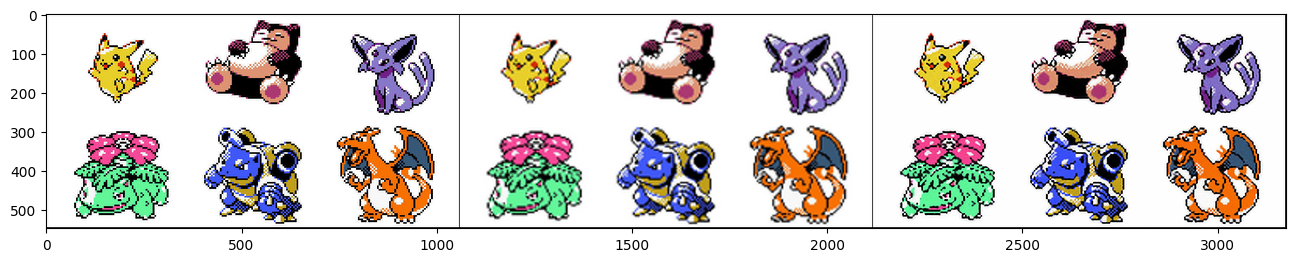

In [26]:
psnr_history = []
net_input_saved = net_input.detach().clone()
noise = net_input.detach().clone()

i = 0
p = get_params(OPT_OVER, net, net_input)
optimize(OPTIMIZER, p, closure, LR, num_iter)

In [27]:
run.finish()

psnr_HR,▁▁▁▂▂▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████
psnr_LR,▁▂▂▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇█████████
psnr_HR,20.415
psnr_LR,31.28152
